#ArgoCycleRepresentation:ResearchNotebook

Thisnotebookdevelopsacompact,queryablesplinerepresentationforindividualArgodepthprofiles.

**Corequestion**:Canwecompresseachprofile(~80observationspercycleformostArgofloats)intoasmoothmodelthatcaptureslarge-scaleverticalstructure,providesuncertaintyestimatesatarbitrarypressures,andservesasinputtospatio-temporalmodeling?

**Approach**:AdaptiveB-splinefittingwithcurvature-guidedknotplacementinformedbyLietal.(2005),LSQratherthanexactinterpolationasaprojectdesignchoiceaimedatnoiserobustness,anddepth-varyinguncertaintyfromsensorspecsandpressure-propagatedgradients(Wongetal.,2025,pp.55-56).

**Context**:ThisbuildsonYargeretal.(2022,pp.11-12)'sfunctionalrepresentationapproachbutuses9-16adaptiveknotspercycleversus200equispacedknots.UnlikeexactinterpolantslikeMRST-PCHIP(Barker&McDougall,2020,pp.1-2),thisoptimizesforcompactrepresentationratherthanSA-CTdiagrampreservation.

**Scope**:Thisnotebookdemonstratesthemethodon469cyclesfromonesubtropicalregion(2011,NorthAtlantic).Itestablishesproof-of-conceptandbaselinevalidationmetricsforthecurrentsplineartifact.ComparativebenchmarkingagainstAkima/PCHIPnowlivesinthecompanionvalidationnotebook;regionalgeneralizationanddeeperfailure-modeanalysisremainfuturework.

##1.Dependencies

In [1]:
import numpy as np
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
from tqdm.auto import tqdm
from matplotlib import pyplot as plt
import seaborn as sns

/home/jcherry/Documents/storage/git/argo-data-interpolation/.venv/bin/python: No module named pip


In [2]:
from lib import ModelError, SensorError, CycleError, CycleModel, CycleSettings

from lib import build_model, calc_fold_error

##2.DataAcquisition

RequestArgoprofilesfromaboundedregionandtimewindow.Thissliceprovidesareproducibleworkingdatasetwhiletuninginterpolationparameters.

**Regionalcontext**:Thissubtropicalbox(20-30°N,75-45°W)isusedhereasapracticalstartingpointforlocalmethoddevelopmentratherthanasaliterature-backedclaimabouttheeasiestormostrepresentativeArgoregime.Performanceinmoredifficultsettingssuchasdeepwintermixedlayers,equatorialinversions,andpolarhaloclinesremainsfuturevalidationwork.

In [3]:
box = [
    -75, -45, ## Longitude min/max
    20, 30, ## Latitude min/max
    0, 3000, ## Pressure/depth min/max
    '2011-01', '2011-06', ## Datetime min/max
]
f = ArgoDataFetcher().region(box).load()
data = f.data.to_dataframe()

##3.ProfileStructure

Transformflatobservationrowsintocycle-indexedprofiles:
-Uniquecycleidentifier(`PLATFORM_CYCLE`)
-Cyclemetadata(position,time)
-Pressure-sortedreadingsformodelfitting

In [4]:
group_col = 'PLATFORM_CYCLE'
group_fields = ['PLATFORM_NUMBER', 'CYCLE_NUMBER']
cycle_fields = ['LATITUDE', 'LONGITUDE', 'TIME']
reading_fields = ['PRES', 'PRES_ERROR', 'PSAL', 'PSAL_ERROR', 'TEMP', 'TEMP_ERROR']

In [5]:
cycles = data[group_fields + cycle_fields].drop_duplicates().sort_values(group_fields)
cycles.index = (cycles[group_fields[0]].astype(str) + '-' + cycles[group_fields[1]].astype(str)).rename('PLATFORM_CYCLE')

In [6]:
readings = data[group_fields + reading_fields].drop_duplicates().sort_values([*group_fields, 'PRES']).reset_index(drop=True)
readings.insert(0, group_col, readings[group_fields[0]].astype(str) + '-' + readings[group_fields[1]].astype(str))
readings = readings.drop(columns=group_fields)

##4.Cycle-LevelModelFitting

Foreachprofile:
1.Estimatevalidationerrorvia5-foldcross-validation
2.Fittemperatureandsalinitysplinemodels
3.Packagemodelswitherrorestimatesin`SplineModel`objects

Theresult:acompactlibrarywhereyouprovideacycleIDandpressure,andgetbackinterpolatedvalueswithuncertainty.

###MethodOverview

Oceanprofileshavemixedstructure:thermoclinesbendsharply,deeplayersareflat.Ratherthanspreadingknotsuniformly,placethemwherecurvatureishighest—moreinthethermocline,fewerintheabyss.Thisfollowscurvature-adaptivesplinefittingprinciplesfromLietal.(2005,pp.791-794),usedhereasacross-domainmethodologicalanalogueratherthandirectoceanographicpriorart.

Useleast-squaresfittingratherthanexactinterpolation.TraditionalexactinterpolantssuchasMR-PCHIPandMRST-PCHIPareconstructedtoreconstructvaluesbetweenretainedobservationswhilelimitingovershootandpreservingphysicallyrealisticstructure,nottoproduceacompactstoredartifact(Barker&McDougall,2020,pp.1-2,4-7,14-15).Inthisnotebook,LSQfittingisaprojectdesignchoiceintendedtorepresentthebroaderprofilestructurewithoutreproducingeverypointexactly.

Uncertaintycombinesmodelerror,aninstrument/errorterm,andpressure-gradientpropagation.Fortemperature,theinstrumenttermisfixedat0.002°C.Forsalinity,thisnotebookdoesnotuseasingleuniversalconstant,becauseArgodelayed-modesalinityuncertaintyistreatedasadjustment-dependentwithaminimumfloorratherthanoneexactvalueeverywhere(Wongetal.,2025,pp.50,55-56,84;Wongetal.,2023,p.9).Instead,itusesthe95thpercentileofeachcycle’s`PSAL_ERROR`values.Asaresult,thislocaluncertaintyconstructionislargestwhereverticalgradientsaresteepest.

Thismethoduses9-16knotspercycle(median~9)versusYargeretal.'s(2022,pp.11-12)200equispacedknots.

###ParameterChoices

The`SplineSettings`usedhere(`prominence=0.25,window=10,spacing=5.0,peak_dist=20,folds=5`)wereselectedthroughinformalexperimentationonasubsetofprofiles.Thesevaluesarelikelyregion-specificandnotnecessarilyoptimal.

Parameterscanbetunedtoachievetighterfitsifneeded,thoughthisincreasesknotcountandcompromisesstorageefficiency.Thetrade-offbetweenrepresentationfidelityandmodelcompactnessisapplication-dependent.Systematicparametertuningandsensitivityanalysisareplannedfuturework.

In [7]:
settings = CycleSettings(
    prominence = 0.25,
    window = 10,
    spacing = 5.0,
    peak_dist = 20,
    folds = 5,
)

cycle_models = {}
for cycle_number, cycle_data in tqdm(readings.groupby('PLATFORM_CYCLE')):
    cycle_data = cycle_data.sort_values('PRES')
    rmse_temp, rmse_sal = calc_fold_error(cycle_data, settings)

    model_temp = build_model(cycle_data['PRES'], cycle_data['TEMP'], settings)
    model_sal = build_model(cycle_data['PRES'], cycle_data['PSAL'], settings)

    sal_95_error = np.nanpercentile(cycle_data['PSAL_ERROR'], 95)

    cycle_error = CycleError(
        model=ModelError(
            temperature=rmse_temp,
            salinity=rmse_sal,
        ),
        sensor=SensorError(
            salinity=sal_95_error,
        ),
    )
    cycle_model = CycleModel(
        temperature=build_model(cycle_data['PRES'], cycle_data['TEMP'], settings),
        salinity=build_model(cycle_data['PRES'], cycle_data['PSAL'], settings),
        error=cycle_error,
        settings=settings,
        pressure_bounds=(cycle_data['PRES'].min(), cycle_data['PRES'].max()),
    )
    cycle_models[cycle_number] = cycle_model

  0%|          | 0/469 [00:00<?, ?it/s]

##5a.Single-CycleInspection

Selectonecyclefordetailedexamination.Doestheinterpolatedprofilelookphysicallyreasonablepoint-by-point,notjustinaggregate?

In [8]:
# cycle_number = np.random.choice(list(cycle_models.keys()))
cycle_number = '6900551-71'
print(f"Cycle #: {cycle_number}")
cycle_data = readings.loc[readings['PLATFORM_CYCLE'] == cycle_number]
cycle_model = cycle_models[cycle_number]

Cycle #: 6900551-71


In [9]:
cycle_interp = cycle_model.interpolate(cycle_data['PRES'])

##5b.UncertaintyEnvelopeConstruction

Constructplottingbandsfromper-pointerrorterms.Use2σasareadableapproximationofalikelyrangearoundeachestimate(notaformalconfidenceinterval).

**Depth-varyinguncertainty**:Theuncertaintyenvelopewidensinthethermoclinewhere|dT/dP|islarge,reflectingthefactthatafixedpressureuncertainty(2.4dbar)contributesmoretotemperatureuncertaintywheregradientsaresteep.IntheflatdeepoceanwheredT/dP→0,pressure-propagatederrorvanishesandonlythefixedinstrument/errortermandmodelresidualsremain.Thepressureandtemperaturesourcetermsusedinthisprototypecomefromthedelayed-modeArgoQCconventionssummarizedinWongetal.(2025,pp.43,47,50,84).

Thethreeerrorterms(modelRMSE,afixedinstrument/errorterm,andpressure-propagatedgradient)arecombinedasroot-sum-square(RSS)foreachquery.Thistreatsthemasindependentcontributions,whichisasimplifyingassumptioninthecurrentprototype.

In [10]:
sd_offset = 2

cycle_interp['temp_low'] = (cycle_interp['temperature'] - (sd_offset * cycle_interp['temp_error']))
cycle_interp['temp_high'] = (cycle_interp['temperature'] + (sd_offset * cycle_interp['temp_error']))
cycle_interp['sal_low'] = (cycle_interp['salinity'] - (sd_offset * cycle_interp['sal_error']))
cycle_interp['sal_high'] = (cycle_interp['salinity'] + (sd_offset * cycle_interp['sal_error']))

##5c.VisualDiagnostic

Interpolatedcurveswith2σenvelopesvia`fill_betweenx`.Pressureincreasesdownward.Wherebandswiden,themodelsignalsgreaterlocaluncertainty.

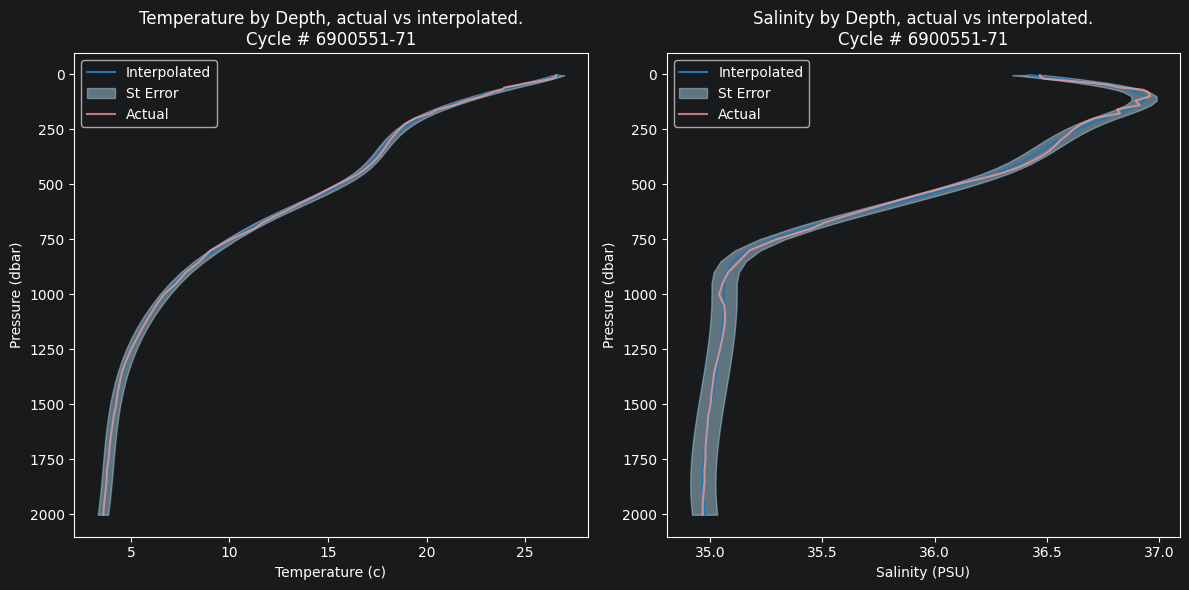

In [11]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

cycle_interp.reset_index().plot(x='temperature', y='pressure', color='#1f78b4', ax=ax[0])
ax[0].fill_betweenx(y=cycle_interp.index, x1=cycle_interp['temp_low'], x2=cycle_interp['temp_high'], color='#a6cee3', alpha=0.5)
cycle_data.plot(x='TEMP', y='PRES', color='#fb9a99', alpha=0.75, ax=ax[0])
ax[0].set(
    title=f"Temperature by Depth, actual vs interpolated."
          f"\nCycle # {cycle_number}",
    xlabel=f"Temperature (c)",
    ylabel=f"Pressure (dbar)",
)
ax[0].invert_yaxis()
ax[0].legend(["Interpolated", "St Error", "Actual"])

cycle_interp.reset_index().plot(x='salinity', y='pressure', color='#1f78b4', ax=ax[1])
ax[1].fill_betweenx(y=cycle_interp.index, x1=cycle_interp['sal_low'], x2=cycle_interp['sal_high'], color='#a6cee3', alpha=0.5)
cycle_data.plot(x='PSAL', y='PRES', color='#fb9a99', alpha=0.75, ax=ax[1])
ax[1].set(
    title=f"Salinity by Depth, actual vs interpolated."
          f"\nCycle # {cycle_number}",
    xlabel=f"Salinity (PSU)",
    ylabel=f"Pressure (dbar)",
)
ax[1].invert_yaxis()
ax[1].legend(["Interpolated", "St Error", "Actual"])

fig.tight_layout()

###Interpretation

Observedprofilefollowsinterpolatedprofilecloselyacrossdepth.Mostpointsfallinsidetheplotted2σband,suggestingthatthecurrentuncertaintyconstructionisinformativeonthisexamplewithoutbeingobviouslyinflated.

##6a.Cross-CycleValidation:RMSEDistributions

Ifthefittingprocedureisstable,validationRMSEshouldclusterinalow-errorregime.Areweconsistentlyaccurate,oronlyaccurateoneasycycles?

**Note**:Thesevaluesquantifywithin-profilereconstructionerrorfrom5-foldcross-validation,notspatio-temporalpredictionerror.Publishedbenchmarksforthisspecifictask(verticalrepresentationaccuracy)arescarceintheliterature.

In [12]:
model_error = pd.DataFrame([model.error.model for model in cycle_models.values()])

In [13]:
pd.concat([
    model_error.mean().rename('mean'),
    model_error.median().rename('median'),
    model_error.std().rename('stdev'),
], axis=1)

,mean,median,stdev
temperature,0.175418,0.145589,0.099711
salinity,0.029466,0.024603,0.016469


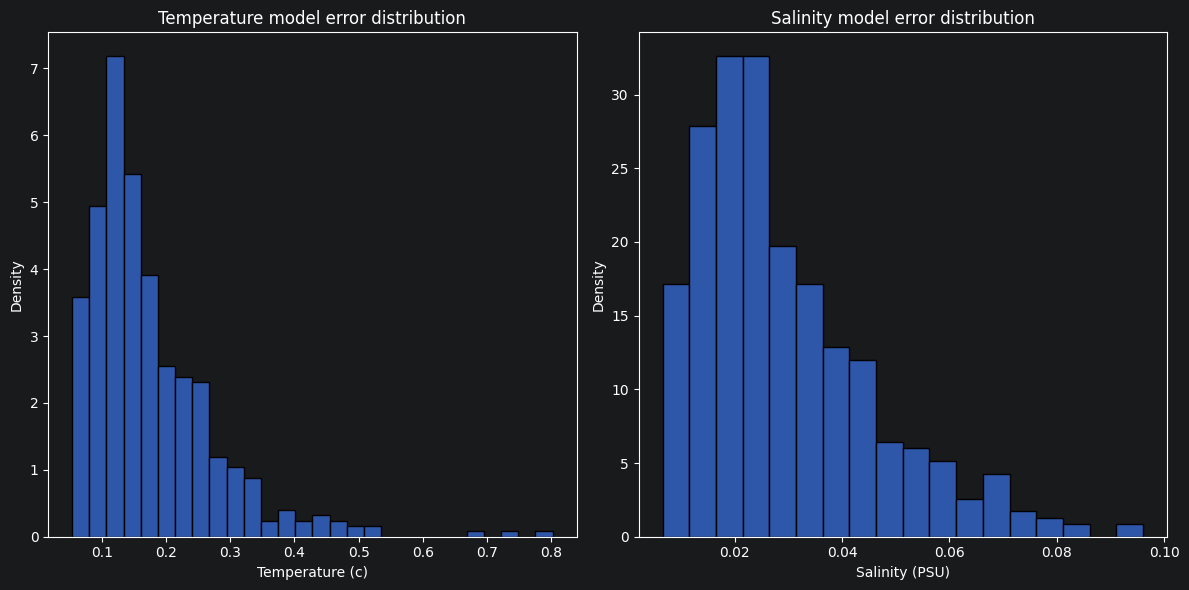

In [14]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

sns.histplot(model_error['temperature'], stat='density', ax=ax[0])
ax[0].set(
    title=f"Temperature model error distribution",
    xlabel=f"Temperature (c)",
)

sns.histplot(model_error['salinity'], stat='density', ax=ax[1])
ax[1].set(
    title=f"Salinity model error distribution",
    xlabel=f"Salinity (PSU)",
)

fig.tight_layout()

###DistributionInterpretation

BothRMSEdistributionsarestronglyright-skewed:mostcyclesfitwell,withasmallertailofdifficultoutliers.Thisisexpectedforoceanprofiledata.Thecentraltendency(mediantemperatureRMSE0.146°C,salinity0.025PSU)isreasonableforcurrentobjectives.High-errortailcasesaretargetedfollow-uptasks.

**Openquestion**:Therighttail(somecycleswithRMSE>0.35°C)deservesinvestigation.Potentialcausesincludeprofileswithstrongsubsurfaceinversions,fine-scalelayering,orsparsesamplingincomplexregions.Identifyingandhandlinghigh-errorcasesisapriorityformakingthismethodproduction-ready.

##6b.ResidualStructurebyDepth

ValidationRMSEtellsusaverageerror,butnotwhereitoccurs.Doresidualsshowsystematicdepthpatterns?

**Question**:Doeserrorcorrelatewithoceanographiccomplexity?Ifadaptiveknotplacementisworking,we'dexpectreasonableerrorsincomplexregions(sharpthermocline,inversions,fine-scaleintrusions)thataveragenearzero,thoughlikelystillelevatedcomparedtosimplerregimes(deepocean,homogeneousmixedlayer).Errorsshouldreflectgenuinemodelingdifficulty,notuniformdistribution.

Note:Thesearepuremodelreconstructionresiduals(0.175°CRMSE).Totalreporteduncertaintyislarger,addingsensorerrorandpressure-propagatedgradienttermsthatvarywithdepth.

In [15]:
error_records = []
for cycle_number, cycle_data in tqdm(readings.groupby('PLATFORM_CYCLE')):
    cycle_model = cycle_models[cycle_number]
    cycle_interp = cycle_model.interpolate(cycle_data['PRES'])
    cycle_values = pd.concat([
        cycle_data.set_index('PRES')['TEMP'].rename('temp_actual'),
        cycle_interp['temperature'].rename('temp_interp'),
        cycle_data.set_index('PRES')['PSAL'].rename('sal_actual'),
        cycle_interp['salinity'].rename('sal_interp'),
    ], axis=1).reset_index().rename(columns={'index': 'pressure'})
    cycle_values['temp_error'] = cycle_values['temp_actual'] - cycle_values['temp_interp']
    cycle_values['sal_error'] = cycle_values['sal_actual'] - cycle_values['sal_interp']
    error_records.append(cycle_values[['pressure', 'temp_error', 'sal_error']])
error_records = pd.concat(error_records, axis=0)

  0%|          | 0/469 [00:00<?, ?it/s]

In [16]:
pd.concat([
    error_records[['temp_error', 'sal_error']].mean().rename('mean'),
    error_records[['temp_error', 'sal_error']].median().rename('median'),
    error_records[['temp_error', 'sal_error']].std().rename('stdev'),
], axis=1)

,mean,median,stdev
temp_error,2.733078e-16,-0.002206,0.179156
sal_error,-6.031722e-16,-0.000261,0.028779


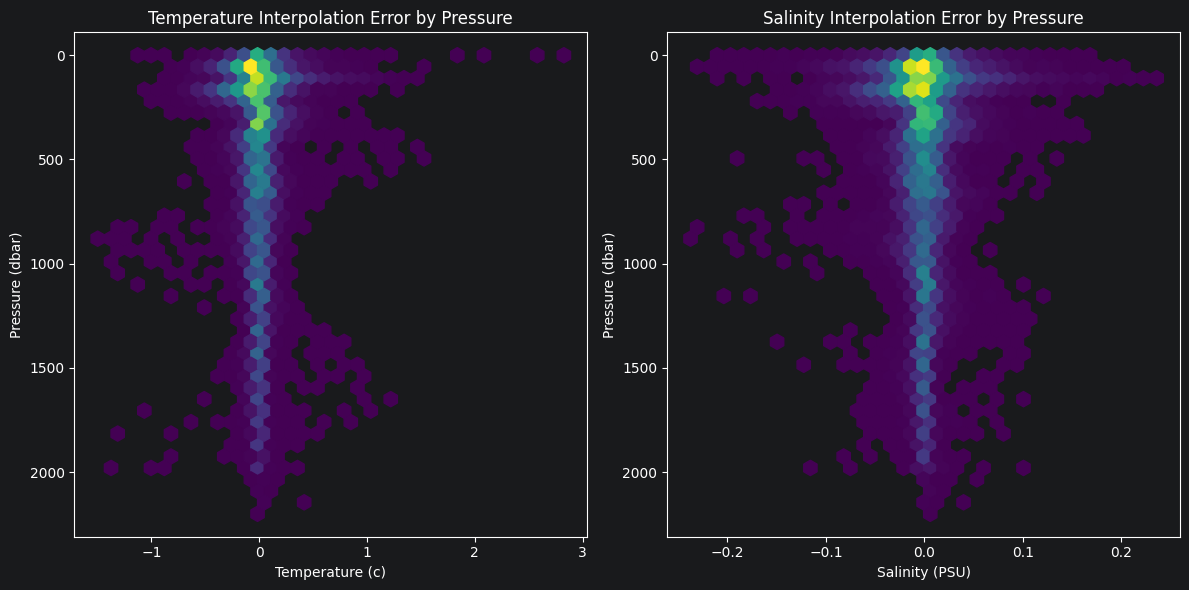

In [17]:
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

ax[0].hexbin(error_records['temp_error'], error_records['pressure'], gridsize=35, mincnt=1, cmap='viridis')
ax[0].invert_yaxis()
ax[0].set(
    title=f"Temperature Interpolation Error by Pressure",
    xlabel=f"Temperature (c)",
    ylabel=f"Pressure (dbar)",
)

ax[1].hexbin(error_records['sal_error'], error_records['pressure'], gridsize=35, mincnt=1, cmap='viridis')
ax[1].invert_yaxis()
ax[1].set(
    title=f"Salinity Interpolation Error by Pressure",
    xlabel=f"Salinity (PSU)",
    ylabel=f"Pressure (dbar)",
)

fig.tight_layout()

###Interpretation

Thehexbinplotsrevealcleardepth-structuredpatterns.Residualsarenotuniformlydistributed—errorvariessystematicallywithdepth.Critically,aggregatecentraltendencyremainsnearzero(meantemperatureerror2.7×10⁻¹⁶°C,salinity-6.0×10⁻¹⁶PSU),confirmingthatthereconstructionresidualsarecenterednearzerointhisprototypesetting,withnoobviousaggregatebiasinthefittedprofiles.

Visualinspectionsuggestserrordensitynarrowsinthedeepocean(below~1500dbar),consistentwiththeexpectationthatstable,low-gradientregionsareeasiertomodel.Thethermoclineregionshowswidererrorspread,asexpectedforcomplexhigh-gradientstructure.

Thisdepth-errorcorrelationsuggestsadaptiveknotplacementisconcentratingeffortappropriately:allocatingflexibilitywherethewatercolumnisgenuinelycomplexwhilestayingsparseinsimplerregimes.Formalquantification—stratifyingresidualsbylocalgradientstrength—isdeferredtofutureworkbutremainsapriorityforvalidatingthattheobservedpatternsmatchoceanographicexpectations.

##7.MethodScopeandCurrentLimitations

**Whatthisnotebookdemonstrates:**
-Proof-of-conceptforadaptivesplinerepresentationofArgoprofiles
-Validationframeworkvia5-foldcross-validation
-Uncertaintyquantificationcombiningsensorspecsandmodelerror
-Near-zeroaggregatereconstructionbiasinthisprototypedataset

**WhatthisnotebookdoesNOTaddress(yet):**
-**Comparativebenchmarking**:AseparatevalidationnotebooknowcomparesthecurrentsplineartifacttoAkimaandPCHIPonthesameinterleavedomitted-pointbenchmark.Thatcomparisonshouldbeusedwheninterpretingwhether0.175°CRMSEisstrongorweakrelativetoexactinterpolants.
-**Failuremodes**:Thehigh-errortail(somecycles>0.35°CRMSE)isunexplained.Whatprofilesbreakthismethod?
-**Regionalgeneralization**:Onlytestedononesubtropicalbox.Doesthisworkinpolarregions?Equatorialupwellingzones?Deepwintermixedlayers?
-**SA-CTpreservation**:UnlikeMRST-PCHIP(Barker&McDougall,2020,pp.1-2),thismethoddoesn'toptimizeforwater-massstructure.Trade-offsarenotquantified.
-**Parametersensitivity**:Currentsettingswereinformallytuned.Howsensitiveareresultstothesechoices?
-**Practicaldeployment**:Computationalcost,workflowintegration,andreproducibilitydetailsarenotcovered.

**Intendeduse**:Thisisaworkingprototypeforexploringcompactprofilerepresentation.Usecautiously,validateonyourowndata,andexpectrefinement.Notyetsuitableasablack-boxproductiontool.

##References

**Referencestatusnote**:Allreferenceslistedherewerecheckedagainstlocalfull-textcopies.TheLietal.(2005)comparisonisstillacross-domainmethodologicalanalogyratherthananoceanographicsourceclaim.

-Barker,P.M.,&McDougall,T.J.(2020).Twointerpolationmethodsusingmultiply-rotatedpiecewisecubicHermiteinterpolatingpolynomials.*JournalofAtmosphericandOceanicTechnology,37*(4),605-619.https://doi.org/10.1175/JTECH-D-19-0211.1
-Li,W.,Xu,S.,Zhao,G.,&Goh,L.P.(2005).AdaptiveknotplacementinB-splinecurveapproximation.*Computer-AidedDesign,37*(8),791-797.https://doi.org/10.1016/j.cad.2004.09.008
-Thielmann,A.,Kneib,T.,&Säfken,B.(2025).Enhancingadaptivesplineregression:Anevolutionaryapproachtooptimalknotplacementandsmoothingparameterselection.*JournalofComputationalandGraphicalStatistics,34*(4),1397-1409.https://doi.org/10.1080/10618600.2025.2450458
-Wong,A.P.S.,Keeley,R.,Carval,T.,&theArgoDataManagementTeam.(2025).*ArgoQualityControlManualforCTDandTrajectoryData*(Version3.9).https://doi.org/10.13155/33951
-Yarger,D.,Stoev,S.,&Hsing,T.(2022).Afunctional-dataapproachtotheArgodata.*TheAnnalsofAppliedStatistics,16*(1),216-246.https://doi.org/10.1214/21-AOAS1477

##NextSteps

Thisnotebookestablishesbaselineperformanceforadaptivecycle-levelrepresentation.Immediatefollow-onworkincludes:

1.**Post-benchmarkanalysis**:ConsolidateAkima/PCHIPcomparisonresults,addcompactness/stabilityinterpretation,andextendthecomparisontoadditionalbaselinesonlyiftheyaddressadistinctmethodologicalquestion
2.**Failureanalysis**:Characterizethehigh-errortail—what'sdifferentaboutdifficultprofiles?
3.**Regionalvalidation**:TestonSouthernOcean,equatorialPacific,andArcticdata
4.**SA-CTdiagnosis**:Quantifywater-masspreservationtrade-offsvs.MRST-PCHIP
5.**Parameteroptimization**:SystematicgridsearchorBayesianoptimizationfor`SplineSettings`

Thebroadergoal:integratethesesplinemodelsintospatio-temporalinterpolationworkflows,wherecompactqueryablerepresentationswithuncertaintybecomeinputstokrigingorGP-basedspatialprediction.